# Word2Vec Model

## **Motivation**

Let's say we have the text message: **I love to learn machine learning.**

How some machine learning model can understand this text? Machine learning models cannot directly understand plain text. They work with numbers, vectors, or matrices, so we need a way to convert words into numerical representations. There are several approaches to do this, and we’ll explore three common ones:

1. One-hot encodings

2. Co-occurrence matrices

3. Word embeddings

## **One-hot encodings**

We assume that out message is the whole language corpus. So, let's firstly split this sentence into separate *tokens*. Token is the single semantic structure. Hence, our unique tokens (we make lower-casing) here are:

In [ ]:
tokens = ['i', 'love', 'to', 'learn', 'machine', 'learning', ]

This means the vocabulary size of our corpus is 6. In one-hot encoding, we represent each word as a vector of the same length as the vocabulary, here, 6 dimensions.

Each vector is filled with zeros, except for the position corresponding to the word, which is set to 1. This creates a unique numerical representation for each word.

| Token    | One-hot vector (6-dim) |
| -------- | ---------------------- |
| i        | [1, 0, 0, 0, 0, 0]     |
| love     | [0, 1, 0, 0, 0, 0]     |
| to       | [0, 0, 1, 0, 0, 0]     |
| learn    | [0, 0, 0, 1, 0, 0]     |
| machine  | [0, 0, 0, 0, 1, 0]     |
| learning | [0, 0, 0, 0, 0, 1]     |

Each word is mapped to a unique vector of length equal to the vocabulary size.

This encoding preserves no information about word similarity, i.e., all words are equally distant from each other.

One-hot encoding is simple and works for small vocabularies but becomes inefficient for larger corpora (hundreds of thousands of words).

In [ ]:
# Create a dictionary to map each token to its index
token_to_index = {token: idx for idx, token in enumerate(tokens)}

# Function to create one-hot vector
def one_hot(token, vocab_size=len(tokens)):
    vector = [0] * vocab_size
    index = token_to_index[token]
    vector[index] = 1
    return vector

# Generate one-hot vectors for all tokens
one_hot_vectors = {token: one_hot(token) for token in tokens}

for token, vector in one_hot_vectors.items():
    print(f"{token}: {vector}")

i: [1, 0, 0, 0, 0, 0]
love: [0, 1, 0, 0, 0, 0]
to: [0, 0, 1, 0, 0, 0]
learn: [0, 0, 0, 1, 0, 0]
machine: [0, 0, 0, 0, 1, 0]
learning: [0, 0, 0, 0, 0, 1]


### Measuring Similarity Between Word Vectors

One way to measure the similarity between vectors is to use **special metrics** such as **cosine similarity**.

**Cosine similarity** measures how similar two vectors are, **regardless of their magnitude**. It is defined as:


$\text{cosine_similarity}(\mathbf{A}, \mathbf{B}) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$


Where:  
- $\mathbf{A} \cdot \mathbf{B}$ = dot product of vectors $\mathbf{A}$ and $\mathbf{B}$  
- $\|\mathbf{A}\|\ $ = magnitude (length) of vector $\mathbf{A}$  

For **one-hot vectors**:

- Two **different words** are **orthogonal**, so their cosine similarity = 0.  
- The **same word** has cosine similarity = 1.  

This illustrates a key limitation of **one-hot encoding**: it **cannot capture word similarity**, because every word is treated as equally different from every other word.

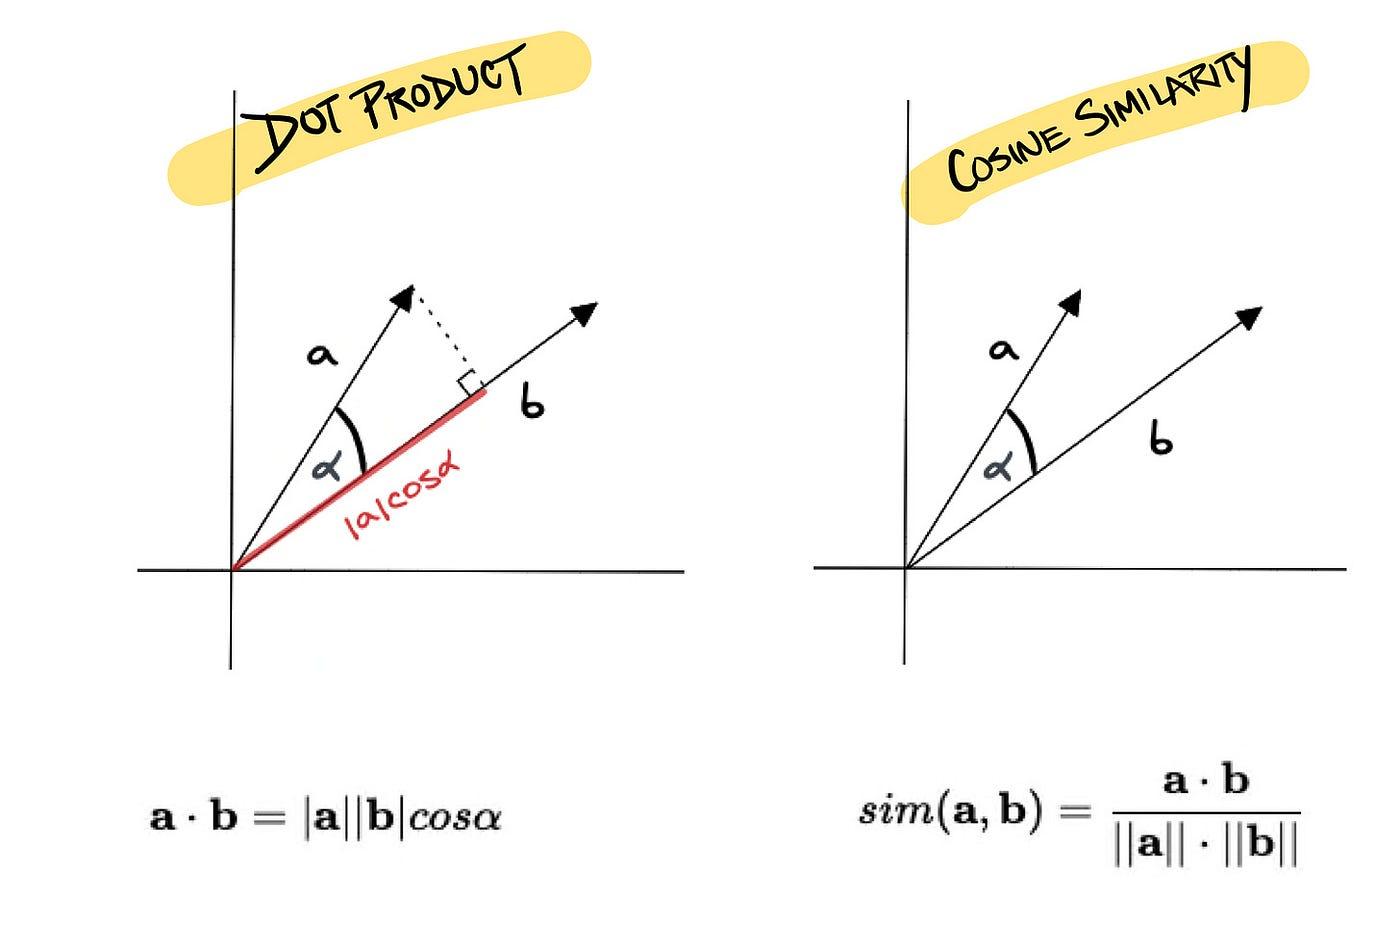

In [ ]:
import numpy as np

# Example vectors
vec_i = one_hot('i')
vec_love = one_hot('love')
vec_learning = one_hot('learning')

# Function to compute cosine similarity
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_product = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    return dot_product / norm_product

# Cosine similarities
print("Similarity (i, i):", cosine_similarity(vec_i, vec_i))
print("Similarity (i, love):", cosine_similarity(vec_i, vec_love))
print("Similarity (learning, love):", cosine_similarity(vec_learning, one_hot('love')))

Similarity (i, i): 1.0
Similarity (i, love): 0.0
Similarity (learning, love): 0.0


## **Co-occurrence matrices**

To overcome the limitation of one-hot encoding, namely, that it **cannot capture semantic similarity between words**, we can consider how words **co-occur** with other words in a corpus.

The key idea is based on the **distributional hypothesis** in linguistics, which states:

> “Words that appear in similar contexts tend to have similar meanings.”

Instead of treating each word as an isolated, independent entity (like in one-hot encoding), we now look at the **patterns of co-occurrence**, i.e., which words appear near each other in sentences or documents.

### How this works:

1. For every word in the vocabulary, we track how often it appears **together with other words** within a certain context window (e.g., ±2 words around it).
2. We construct a **co-occurrence matrix**, where:

   * **Rows** represent target words.
   * **Columns** represent context words.
   * **Entries** are counts of how often the target word appears near the context word.
3. Words that share similar contexts will have **similar rows** in this matrix, allowing us to measure their semantic similarity.

For example, in the sentence:

> “I love to learn machine learning”

* The word **“machine”** often appears near **“learning”**, so their co-occurrence count is high.
* Words like **“i”** and **“machine”** may rarely appear together, so their co-occurrence count is low.

By representing words this way, we capture **meaning through context**, not just arbitrary identity. This is the foundation for more advanced approaches like **word embeddings**, which are continuous, dense vector representations learned from co-occurrence patterns.

In [ ]:
# Initialize co-occurrence matrix
cooc_matrix = np.zeros((6, 6), dtype=int)
tokens = ['i', 'love', 'to', 'learn', 'machine', 'learning', ]

window_size = 1

for i, token in enumerate(tokens):
    token_idx = token_to_index[token]

    # Look at the window before and after the token
    start = max(i - window_size, 0)
    end = min(i + window_size + 1, len(tokens))

    for j in range(start, end):
        if i != j:  # skip the token itself
            context_idx = token_to_index[tokens[j]]
            cooc_matrix[token_idx][context_idx] += 1

print("Co-occurrence Matrix:")
print(cooc_matrix)

Co-occurrence Matrix:
[[0 1 0 0 0 0]
 [1 0 1 0 0 0]
 [0 1 0 1 0 0]
 [0 0 1 0 1 0]
 [0 0 0 1 0 1]
 [0 0 0 0 1 0]]


Using the co-occurrence matrix approach, we can now capture some similarity between words that appear in similar contexts. For example, words like "machine" and "learning" may appear together, so their vectors will reflect this relationship.

However, this method still has a limitation: the vectors are sparse.

In our small example, the corpus contains only 6 words, so the vectors are relatively short and not very sparse.

In a real-world scenario with all words in a language, most words will rarely appear together, so the co-occurrence vectors will contain mostly zeros.

This sparsity is problematic because:

1.   It makes storing and processing the vectors inefficient.
2.   It makes it harder to measure similarity between words, since most vectors have little overlap.


Thus, while co-occurrence matrices improve over one-hot encodings by capturing some contextual similarity, they still face limitations when applied to large vocabularies.

## **Word embeddings**


The main idea behind **word embeddings** is similar to that of the **co-occurrence matrix**: words that appear in similar contexts should have similar representations. However, while co-occurrence matrices are often **high-dimensional and sparse**, word embeddings aim to produce **dense vectors**, typically with **100–300 dimensions**, that are more efficient and capture semantic relationships better.

For illustration purposes, a 2-dimensional word embedding might look like this:

```
i       = [0.14, 0.82]
love    = [0.90, 0.32]
machine = [0.901, -0.23]
...
```

---

### Latent Semantic Analysis (LSA)

This approach was first introduced in the **1990s** by Deerwester et al. in the paper *“Indexing by Latent Semantic Analysis”*.

* **Idea:** Compress the co-occurrence matrix into a lower-dimensional space using **Singular Value Decomposition (SVD)**.
* **Result:** Each word is represented by a dense vector capturing latent semantic structure.
* **Limitation:** While LSA produces dense vectors, it is **count-based** and does not scale as efficiently as predictive models for very large corpora.

---

### Neural / Predictive Word Embeddings (2013–present)

In the early 2000s, Bengio et al. introduced the first **neural probabilistic language model**, which used a **neural network to learn word embeddings**. This was the first time embeddings were trained with a neural network, rather than purely from co-occurrence counts.

In **2013**, Google researchers (Mikolov et al.) popularized **Word2Vec** in the paper *“Efficient Estimation of Word Representations in Vector Space”*.

* **Idea:** Train models to **predict a word from its context** (CBOW) or **predict context words from a target word** (Skip-gram), resulting in **dense, low-dimensional vectors**.
* **Other approaches:**

  * **GloVe (Pennington et al., 2014):** Combines count-based co-occurrence statistics with a predictive model.
  * **FastText (Bojanowski et al., 2017):** Extends Word2Vec with subword (character n-gram) information.

**Pros of predictive embeddings:**

* Dense vectors (low-dimensional).
* Capture semantic and syntactic relationships.
* Scalable to large corpora.

**Cons:**

* Pretrained embeddings may not generalize well to domain-specific language.

**Word2Vec** was proposed in **2013** to learn **dense word embeddings** using neural networks trained on huge datasets containing billions of words. The paper introduced **two main approaches** to learn embeddings: **Continuous Bag-of-Words (CBOW)** and **Skip-gram (SG)**. For illustration, we will use a **window size of 2**.

Our example corpus:

```
i love to learn machine learning
```

---

### Continuous Bag-of-Words Model (CBOW)

**Idea:** Predict the **center word** given its **context words**.

With a window size of 2, for the word `"to"` as the center, the context words are:

```
i, love, learn, machine
```

The CBOW model tries to predict:

```
Center word: to
Given context: i, love, learn, machine
```

Another example: For center `"machine"`, the context is:

```
to, learn, learning
```

The model tries to predict `"machine"` from these context words.

---

### Skip-gram Model (SG)

**Idea:** Predict the **context words** given the **center word**.

For the center word `"learn"` with a window size of 2, the context words are:

```
love, to, machine, learning
```

The Skip-gram model tries to predict:

```
Center word: learn
Predict context words: love, to, machine, learning
```

---

**Summary of CBOW vs Skip-gram:**

| Model | Input         | Output        | Intuition                             |
| ----- | ------------- | ------------- | ------------------------------------- |
| CBOW  | Context words | Center word   | Predict center word from context      |
| SG    | Center word   | Context words | Predict surrounding words from center |

---

## **Model Architecture**

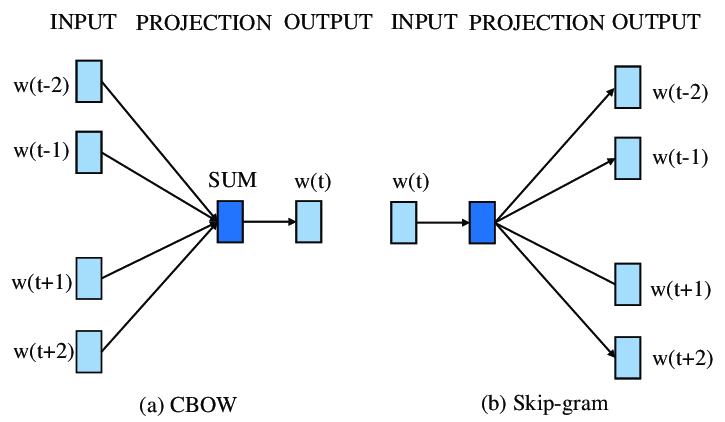

## Continuous Bag-of-Words (CBOW) with W1 and W2

**Goal:** Predict the **center word** given the **context words**.

### Architecture:

1. **Input Layer:**

   * One-hot vectors of the context words.

2. **Embedding / Projection Layer (W1):**

   * Each one-hot vector is multiplied by a **weight matrix (W_1)** of shape (V $\times$ N) (V = vocabulary size, N = embedding size).
   * This converts one-hot vectors into **dense embeddings**.

3. **Hidden Representation:**

   * CBOW **averages** the embeddings of all context words to get a single hidden vector.

4. **Output Layer (W2):**

   * The hidden vector is multiplied by another weight matrix (W_2) of shape (N \times V).
   * Apply **softmax** to get the probability distribution over the vocabulary, predicting the **center word**.

**Summary:**

```
Context words (one-hot) → W1 → Embeddings → Average → W2 → Softmax → Center word
```

* After training, the **rows of W1** (or sometimes the average of W1 and W2) are used as the **word embeddings**.

---

## Skip-gram (SG) with W1 and W2

**Goal:** Predict **context words** given the **center word**.

### Architecture:

1. **Input Layer:**

   * One-hot vector of the **center word**.

2. **Embedding / Projection Layer (W1):**

   * Multiply by **weight matrix (W_1)** (shape (V $\times$ N)) to get the embedding of the center word.

3. **Output Layer (W2):**

   * Multiply the hidden embedding by **W2** (shape (N $\times$ V)) for **each context word**.
   * Apply **softmax** to predict the probability distribution of each context word.

**Summary:**

```
Center word (one-hot) → W1 → Embedding → W2 → Softmax → Predict context words
```

---

### Key Notes:

* **W1**: Projects from **vocabulary space → embedding space**.

* **W2**: Projects from **embedding space → vocabulary space** for prediction.

* After training: the **rows of W1** are typically taken as the **final word embeddings**.

* CBOW **averages context embeddings** before multiplying by W2.

* Skip-gram uses the **center word embedding** to predict multiple context words.

---

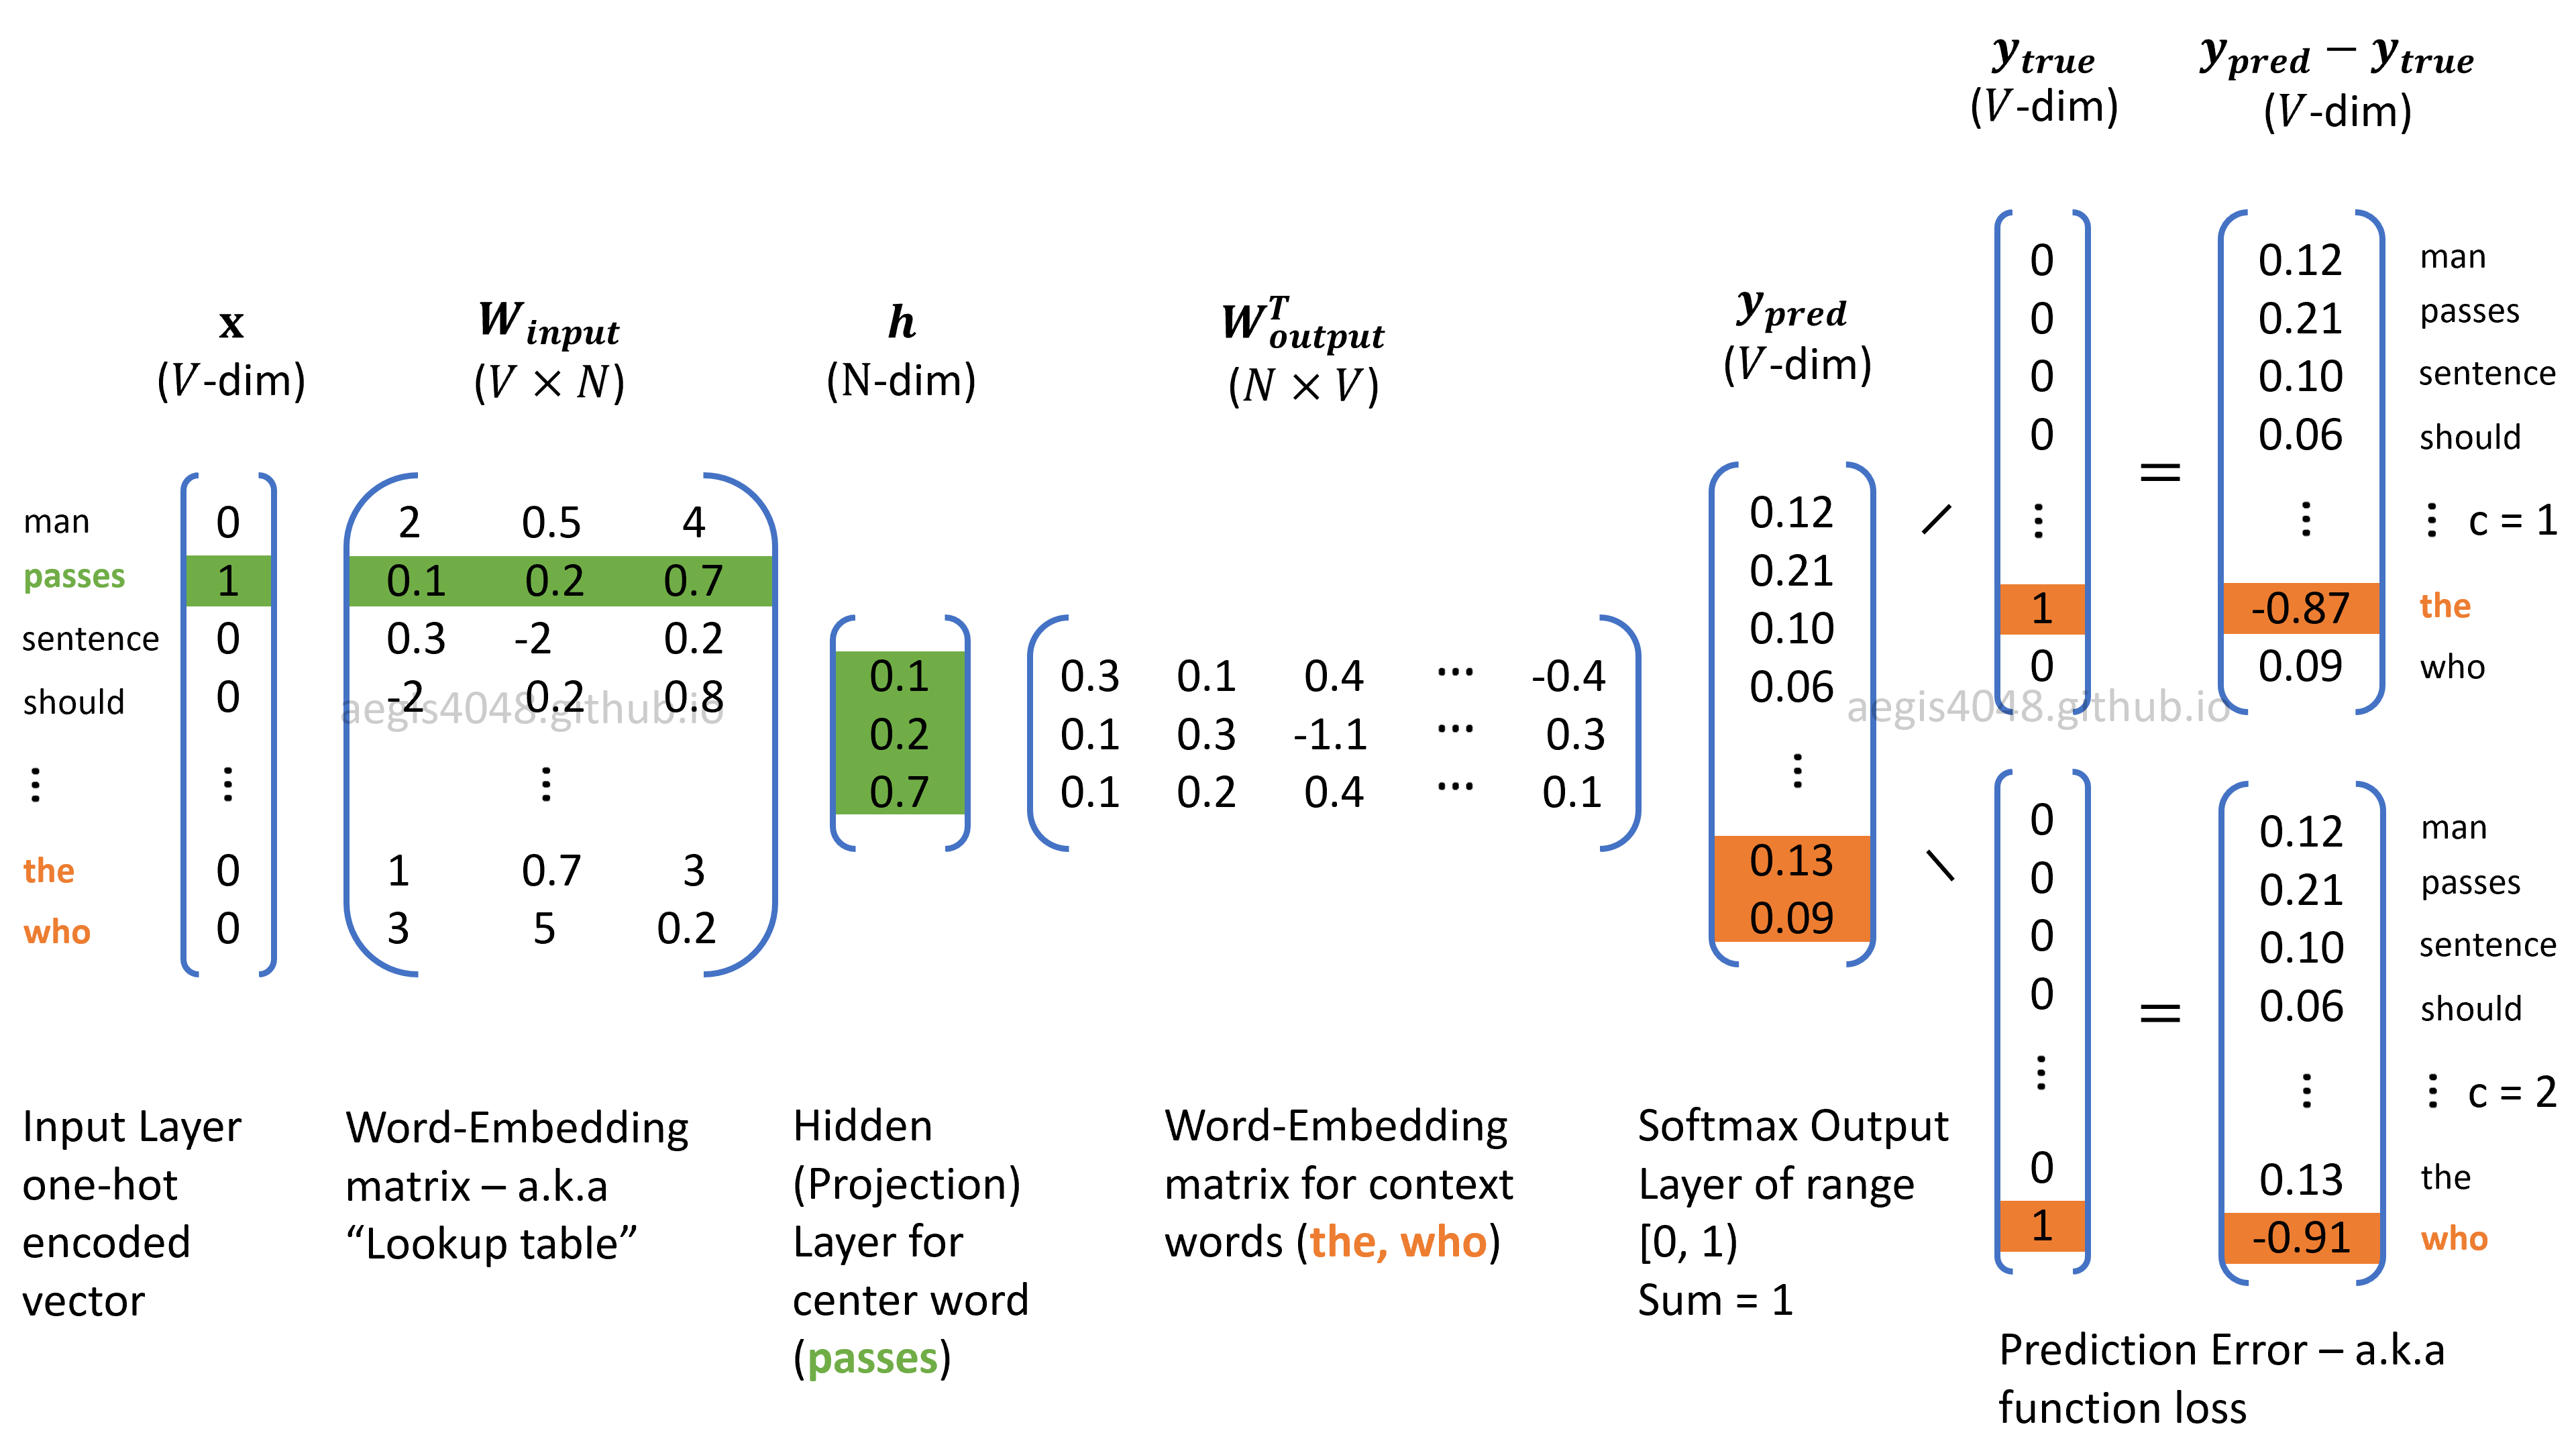

## **Let's manually perform one iteration for skip-gram model**

In [ ]:
# Step 1: Define vocabulary and indexing

tokens = ['i', 'love', 'to', 'learn', 'machine', 'learning']
token_to_index = {token: idx for idx, token in enumerate(tokens)}
index_to_token = {idx: token for token, idx in token_to_index.items()}
vocab_size = len(tokens)
embedding_dim = 3

In [ ]:
# Step 2: Initialize weight matrices W1 and W2 randomly
np.random.seed(42)
W1 = np.random.rand(vocab_size, embedding_dim)  # Input → Hidden
W2 = np.random.rand(embedding_dim, vocab_size)  # Hidden → Output

In [ ]:
# Step 3: One-hot encoding function
def one_hot(token, vocab_size=vocab_size):
    vec = np.zeros(vocab_size)
    vec[token_to_index[token]] = 1
    return vec

In [ ]:
# Step 4: Define sentence and context
sentence = ['i', 'love', 'to', 'learn', 'machine', 'learning']
center_word = 'to'
window_size = 1

# Get context words for skip-gram
center_idx = sentence.index(center_word)
start = max(center_idx - window_size, 0)
end = min(center_idx + window_size + 1, len(sentence))
context_words = [sentence[i] for i in range(start, end) if i != center_idx]

print("Center word:", center_word)
print("Context words:", context_words)

Center word: to
Context words: ['love', 'learn']


In [ ]:
# Step 5: Forward pass
# Input: one-hot vector for center word
I = one_hot(center_word)  # shape (vocab_size,)

# Hidden layer
h = np.dot(I, W1)  # shape (embedding_dim,)
print("Hidden layer (h):", h)

# Output layer (scores)
u = np.dot(h, W2)  # shape (vocab_size,)
print("Output scores (u):", u)

Hidden layer (h): [0.05808361 0.86617615 0.60111501]
Output scores (u): [0.7853302  0.79952094 0.24759478 1.02390925 1.1105601  0.54745364]


### Softmax Function

The **softmax function** is used in neural networks to convert a vector of real-valued scores into a **probability distribution** over possible classes (or words in Word2Vec).

For a vector of scores $\mathbf{z} = [z_1, z_2, \dots, z_n]$, the softmax function is defined as:

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}
$$

Where:  
- $z_i$ is the score for the $i$-th class (or word)  
- $n$ is the total number of classes  
- The denominator $\sum_{j=1}^{n} e^{z_j}$ ensures that **all probabilities sum to 1**.

**Properties of softmax:**  
1. $0 \leq \text{softmax}(z_i) \leq 1$ for all $i$  
2. $\sum_{i=1}^{n} \text{softmax}(z_i) = 1$  
3. Softmax emphasizes the largest scores, making them more likely after normalization.  

In Word2Vec, softmax is applied to the output of the hidden layer to obtain the **predicted probabilities of each word in the vocabulary** being a context word.

In [ ]:
# Step 6: Softmax to get probabilities
def softmax(x):
    e_x = np.exp(x - np.max(x))  # for numerical stability
    return e_x / e_x.sum()

y_pred = softmax(u)
print("Predicted probabilities:", y_pred)

Predicted probabilities: [0.16555046 0.1679165  0.09669296 0.21015705 0.2291796  0.13050343]


### Cross-Entropy Loss for Context Words

In the Skip-gram Word2Vec model, the goal is to **predict the context words given a center word**.  
Since the output of the model is a **probability distribution** over the vocabulary (computed using softmax), we need a loss function that measures **how close the predicted distribution is to the true distribution** of context words.

The **true distribution** for each context word is a **one-hot vector**, where the correct word has probability 1 and all others 0.  

The **cross-entropy loss** is a natural choice for this, because it measures the **difference between two probability distributions**. Minimizing cross-entropy maximizes the probability assigned to the correct context words.

---

### Definition

For a single predicted probability distribution $\mathbf{\hat{y}} = [\hat{y}_1, \hat{y}_2, \dots, \hat{y}_V]$ and a true one-hot vector $\mathbf{y} = [y_1, y_2, \dots, y_V]$, the **cross-entropy loss** is:

$$
L(\mathbf{y}, \mathbf{\hat{y}}) = - \sum_{i=1}^{V} y_i \log(\hat{y}_i)
$$

Where:  
- $V$ = vocabulary size  
- $y_i = 1$ for the correct context word, $0$ otherwise  
- $\hat{y}_i$ = predicted probability for word $i$  

**Intuition:**  
- If the model predicts a high probability for the correct word, $\hat{y}_i \approx 1$, the loss is **small**.  
- If the model predicts a low probability for the correct word, $\hat{y}_i \approx 0$, the loss is **large**.  

In Skip-gram, since there can be **multiple context words**, the total loss is typically computed as the **average (or sum) of the cross-entropy losses** for all context words of a center word:

$$
L_\text{total} = \frac{1}{C} \sum_{c=1}^{C} L(\mathbf{y}^{(c)}, \mathbf{\hat{y}}^{(c)})
$$

Where $C$ is the number of context words.

In [ ]:
# Step 7: Compute cross-entropy loss for context words
losses = []
for context_word in context_words:
    target = one_hot(context_word)
    loss = -np.sum(target * np.log(y_pred + 1e-8))  # add epsilon to avoid log(0)
    losses.append(loss)

total_loss = np.mean(losses)
print("Total loss:", total_loss)

Total loss: 1.672094266203578


In [ ]:
# Step 8: Extract embedding of a word from W1
embedding_center = W1[token_to_index[center_word]]
print(f"Embedding for '{center_word}':", embedding_center)

Embedding for 'to': [0.05808361 0.86617615 0.60111501]


### Negative Sampling

* In the classical skip-gram without optimizations, we compute **softmax over the entire vocabulary**.

  * For a large vocabulary $V = 100{,}000$, this means for **each target word**, we would need to compute probabilities for **all 100k words**.
  * Very expensive.

* **Negative sampling** replaces softmax with a small, “local” task:

  * Take **only the real context word** → **positive word**
  * Take a few **random words that are not in the context** → **negative words**
  * Compute the loss **only** for these words (1 positive + $k$ negatives)

---

### How it works

For a target word $w_t$ and a context word $w_c$:

1. **Positive pair** $(w_t, w_c)$ → maximize the probability that $w_c$ is in the context of $w_t$.
2. **$k$ negative words** $(w_t, w_{n_i})$ → minimize the probability that $w_{n_i}$ is in the context of $w_t$.

---

### Loss function

For one target-context pair:

$ L = -\log \sigma (u_c^T h_t) - \sum_{i=1}^{k} \log \sigma (-u_{n_i}^T h_t) ,$

where:

* $h_t$ — embedding of the target word
* $u_c$ — embedding of the positive context word
* $u_{n_i}$ — embedding of the $i$-th negative word
* $\sigma$ — sigmoid function

---

###  Why it is efficient

* Instead of computing **100,000 logits**, we compute only **1 positive + $k$ negatives**, which is much faster.
* Memory and computation scale with $k$ instead of $V$.

---

###  Summary

| Positive words    | Real context words of the target                                                    |
| ----------------- | ----------------------------------------------------------------------------------- |
| Negative words    | Random words that are **not** context                                               |
| Negative sampling | Compute the loss only for this small set of words, instead of the entire vocabulary |

# **PyTorch example of CBOW model**

Since researchers typically train Word2Vec models on billions of words using massive computing resources, we will simplify things for educational purposes. Our goal is to understand the approach and reproduce it on an average home computer, so we will create a small synthetic corpus with only 21 unique words.

We will create three thematic groups of words and generate random sequences within each group to simulate realistic contexts.

In [ ]:
import torch
import random

random.seed(42)
torch.manual_seed(42)

nature_words  = ['tree', 'river', 'mountain', 'flower', 'leaf', 'forest', 'sky']
school_words  = ['teacher', 'student', 'class', 'book', 'lesson', 'exam', 'school']
royalty_words = ['king', 'queen', 'palace', 'crown', 'castle', 'empire', 'throne']

We will shuffle each group and generate long sequences by repeating the process many times. Words from one group will only appear with words from the same group, preserving contextual relationships.

In [ ]:
def generate_structured_corpus(n_iter=1000):
    """
    Create a corpus that gives different words distinct contexts.
    We mix:
      - repeated templated short phrases (to build strong associations)
      - some shuffled blocks for variety
    """
    parts = []
    for _ in range(n_iter):
        parts.append("tree leaf flower")              # tree nearby leaf/flower
        parts.append("river mountain sky")            # river with mountain/sky
        parts.append("forest tree leaf")              # forest with tree/leaf

        parts.append("teacher student class")         # teacher with student/class
        parts.append("book lesson class")             # book/lesson/class

        parts.append("king queen palace")             # king with queen/palace
        parts.append("crown throne castle")           # crown with throne/castle

        # occasional shuffled block for variety (not dominating)
        random.shuffle(nature_words)
        parts.append(" ".join(nature_words))
        random.shuffle(school_words)
        parts.append(" ".join(school_words))
        random.shuffle(royalty_words)
        parts.append(" ".join(royalty_words))

    return " ".join(parts)

In [ ]:
text = generate_structured_corpus(n_iter=250)
tokens = text.split()

In [ ]:
display(text)

'tree leaf flower river mountain sky forest tree leaf teacher student class book lesson class king queen palace crown throne castle river flower leaf mountain sky tree forest book school class lesson teacher exam student crown palace castle queen empire throne king tree leaf flower river mountain sky forest tree leaf teacher student class book lesson class king queen palace crown throne castle leaf tree river mountain forest flower sky student lesson exam school book class teacher throne crown queen empire palace king castle tree leaf flower river mountain sky forest tree leaf teacher student class book lesson class king queen palace crown throne castle forest flower tree river sky mountain leaf exam book lesson class school student teacher crown throne empire king castle queen palace tree leaf flower river mountain sky forest tree leaf teacher student class book lesson class king queen palace crown throne castle tree sky river flower leaf forest mountain school lesson student class ex

Now, let's create out context words for CBOW model

In [ ]:
# Vocabulary / indices

vocab = sorted(set(tokens))
w2i = {w:i for i,w in enumerate(vocab)}
i2w = {i:w for w,i in w2i.items()}

def generate_cbow_index_pairs(tokens, w2i, window_size=2):
    """
    Return list of (context_idx_list, target_idx)
    context_idx_list length == 2*window_size
    """
    pairs = []
    for i, target in enumerate(tokens):
        left = tokens[max(0, i-window_size): i]
        right = tokens[i+1 : i+window_size+1]
        context = left + right
        if len(context) == 2*window_size:
            context_idxs = [w2i[w] for w in context]
            target_idx = w2i[target]
            pairs.append((context_idxs, target_idx))
    return pairs

window = 2
cbow_pairs = generate_cbow_index_pairs(tokens, w2i, window_size=window)
print("Vocab size:", len(vocab), "CBOW pairs:", len(cbow_pairs))

Vocab size: 21 CBOW pairs: 10496


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


class CBOWDataset(Dataset):
    def __init__(self, cbow_pairs):
        self.pairs = cbow_pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        context_idxs, target_idx = self.pairs[idx]
        return torch.tensor(context_idxs, dtype=torch.long), torch.tensor(target_idx, dtype=torch.long)

batch_size = 128
dataset = CBOWDataset(cbow_pairs)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

## CBOW (Continuous Bag-of-Words) Architecture

1. **Input Layer:**  
   - The input consists of a set of **context words** surrounding the target word.
   - Each word is represented as a **one-hot vector**.

2. **Hidden Layer Calculation:**  
   - The hidden layer $ \mathbf{h} $ is computed by **multiplying the input vector(s) with the weight matrix $ W_1 $**:
     $\mathbf{h} = W_1 \cdot \mathbf{x}_{\text{context}}$
   - For multiple context words, CBOW **aggregates** them first (sum or average) before multiplying by $W_1$:

     $\mathbf{h} = W_1 \cdot (\mathbf{x}_1 + \mathbf{x}_2 + \dots + \mathbf{x}_n) \quad \text{or} \quad
     \mathbf{h} = W_1 \cdot \frac{\mathbf{x}_1 + \mathbf{x}_2 + \dots + \mathbf{x}_n}{n}
     $

3. **Output Layer:**  
   - The hidden vector \( \mathbf{h} \) is then multiplied by the second weight matrix \( W_2 \) and passed through **softmax** to predict the target word.

4. **Result:**  
   - Each training pair is represented as:
     $
     (\text{aggregated context vectors } \mathbf{x}_{\text{context}}, \text{target vector } \mathbf{y})
     $
   - The CBOW model learns $ W_1 $ and $ W_2 $, and the rows of $ W_1 $ become the **word embeddings**.


**Now, let's create the PyTorch model**

In [ ]:
import torch.nn as nn

class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.out = nn.Linear(embed_dim, vocab_size, bias=False)  # maps hidden -> vocab logits

    def forward(self, contexts):  # contexts: (batch, context_size)
        embs = self.embed(contexts)          # (batch, context_size, embed_dim)
        h = embs.mean(dim=1)                 # average context: (batch, embed_dim)
        logits = self.out(h)                 # (batch, vocab_size)
        return logits

In [ ]:
vocab_size = len(vocab)
model = CBOWModel(vocab_size=vocab_size, embed_dim=10)
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

def train(model, loader, epochs=10):
    model.train()
    for epoch in range(1, epochs+1):
        total_loss = 0.0
        for contexts, targets in loader:
            logits = model(contexts)
            loss = loss_fn(logits, targets)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item() * contexts.size(0)
        avg = total_loss / len(loader.dataset)
        print(f"Epoch {epoch}/{epochs} — avg loss: {avg:.4f}")

train(model, loader, epochs=10)

Epoch 1/10 — avg loss: 2.2946
Epoch 2/10 — avg loss: 1.4166
Epoch 3/10 — avg loss: 1.2312
Epoch 4/10 — avg loss: 1.1662
Epoch 5/10 — avg loss: 1.1284
Epoch 6/10 — avg loss: 1.1016
Epoch 7/10 — avg loss: 1.0809
Epoch 8/10 — avg loss: 1.0644
Epoch 9/10 — avg loss: 1.0500
Epoch 10/10 — avg loss: 1.0396


In [ ]:
def most_similar(word, model, w2i, i2w, top_k=5):
    if word not in w2i:
        raise ValueError(word + " not in vocab")
    emb_weights = model.embed.weight.detach()  # (vocab, emb_dim)
    q = emb_weights[w2i[word]]
    # cosine similarity with all others
    sims = (emb_weights @ q) / (emb_weights.norm(dim=1) * q.norm() + 1e-8)
    top = torch.topk(sims, top_k+1)  # includes the word itself
    results = []
    for idx, score in zip(top.indices.tolist(), top.values.tolist()):
        w = i2w[idx]
        if w == word:
            continue
        results.append((w, float(score)))
        if len(results) >= top_k:
            break
    return results

print("Top similar to 'sky':", most_similar('sky', model, w2i, i2w, top_k=5))

Top similar to 'sky': [('flower', 0.6649015545845032), ('river', 0.3667903542518616), ('forest', 0.32664114236831665), ('mountain', 0.21918854117393494), ('book', 0.2181546539068222)]


In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt


def plot_tsne(model, i2w, w2i, highlight_word=None, top_k=5):
    emb = model.embed.weight.detach().cpu().numpy()
    emb = normalize(emb)

    n = emb.shape[0]
    perplexity = min(30, max(2, (n - 1) // 3))

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        metric="cosine",
        init="random",
        random_state=42
    )

    coords = tsne.fit_transform(emb)

    similar_words = set()

    if highlight_word is not None:
        similar_words = {
            word
            for word, _ in most_similar(
                highlight_word,
                model,
                w2i,
                i2w,
                top_k=top_k
            )
        }

        similar_words.add(highlight_word)
    plt.figure(figsize=(12, 9))

    for i, word in i2w.items():

        if word in similar_words:

            plt.scatter(
                coords[i, 0],
                coords[i, 1],
                s=100,
                facecolors="none",
                edgecolors="red",
                linewidths=2
            )

            plt.text(
                coords[i, 0] + 0.02,
                coords[i, 1] + 0.02,
                word,
                fontsize=11,
                fontweight="bold",
                color="red"
            )

        else:

            plt.scatter(
                coords[i, 0],
                coords[i, 1],
                s=30,
                color="steelblue"
            )

            plt.text(
                coords[i, 0] + 0.02,
                coords[i, 1] + 0.02,
                word,
                fontsize=9
            )

    plt.title(
        f"t-SNE of CBOW embeddings"
        + (f" similar to '{highlight_word}'" if highlight_word else "")
    )

    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

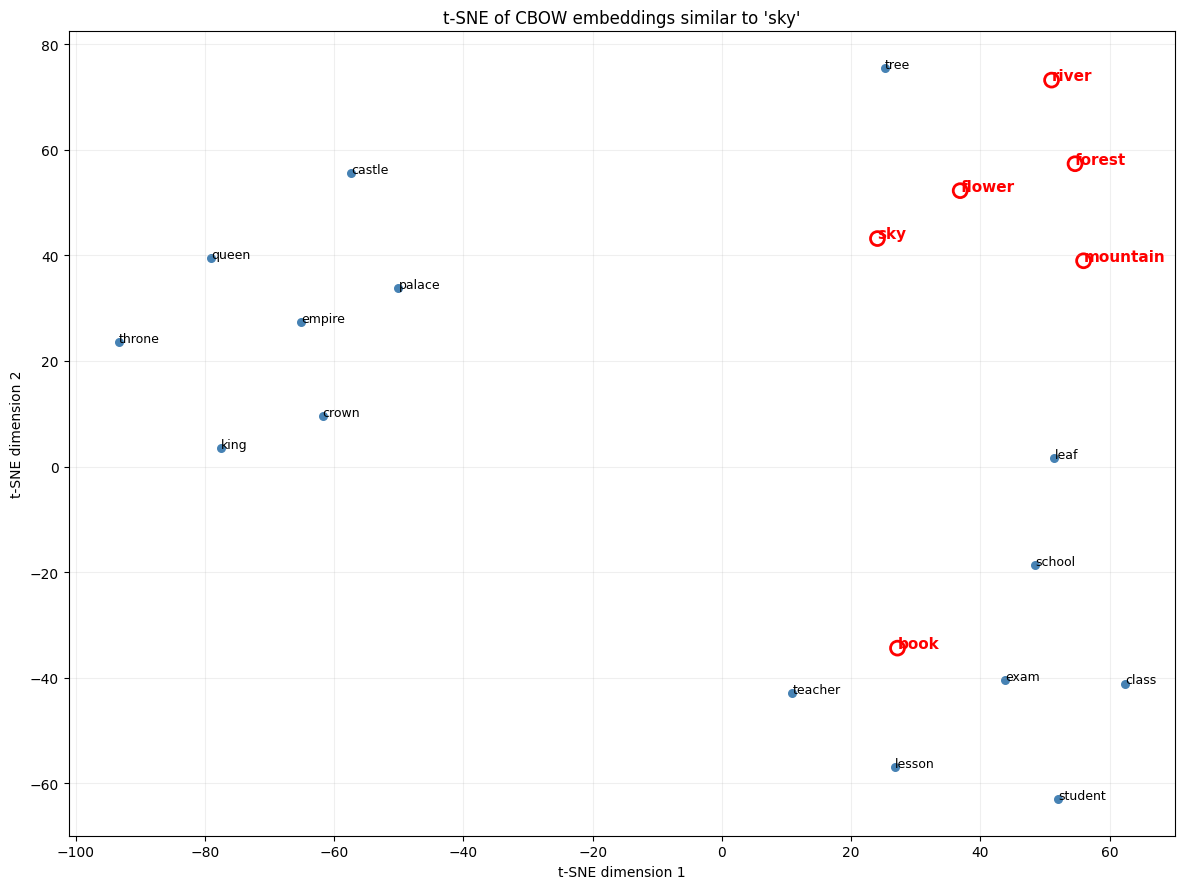

In [ ]:
plot_tsne(
    model,
    i2w,
    w2i,
    highlight_word="sky",
    top_k=5
)

**Word2Vec nice references**:
1. [StatQuest](https://www.youtube.com/watch?v=viZrOnJclY0)
2. [Jay Allamar](https://www.youtube.com/watch?v=ISPId9Lhc1g)
3. [Original Paper](https://arxiv.org/pdf/1301.3781)
4. [Small manual example](https://docs.google.com/document/d/1SJm_-wDau5-Anc3Qb5ooi-pml5F50KuogrL9F_FsAOk/edit?usp=sharing)

**PyTorch**:

1. https://docs.pytorch.org/tutorials/

2. Daniel Godoy. Deep Learning with PyTorch Step-by-Step Beginner's Guide.

P.S. Beyond Word2Vec, several other word embedding models have been developed to capture richer semantic and contextual information.

**GloVe (Global Vectors)** creates embeddings by factorizing a co-occurrence matrix, leveraging global statistical information from the entire corpus.

**FastText**, developed by Facebook, improves on Word2Vec by representing words as subword character n-grams, which helps handle rare words and morphology better.

More recent models like **ELMo (Embeddings from Language Models)** generate context-dependent embeddings using deep bidirectional LSTMs, allowing the same word to have different representations depending on its usage.

Transformer-based models such as **BERT (Bidirectional Encoder Representations from Transformers)** push this further by using attention mechanisms to capture deep contextual relationships, producing powerful embeddings for a wide range of natural language processing tasks.*

# **PCA (Principle Component Analysis )**

Embedding vectors often have very high dimensions, which can make them difficult to interpret and computationally expensive to work with. To address these challenges, it is useful to reduce their dimensionality while retaining as much of the original information as possible. Dimensionality reduction not only helps in visualizing embeddings by projecting them into two or three dimensions for human interpretation, but also lowers the computational cost for downstream tasks such as clustering, classification, or similarity search. Techniques such as **Principal Component Analysis (PCA)**, **t-Distributed Stochastic Neighbor Embedding (t-SNE)**, and **Uniform Manifold Approximation and Projection (UMAP)** are commonly employed for this purpose. These methods aim to preserve the essential structure and relationships within the data, so that the reduced representation remains informative and meaningful for analysis.

For now, let us build intuition around a simple, but powerful technique for dimensionality reduction; **Principal Component Analysis (PCA)**.

## **PCA intuition**

Given 2 dimensional space let's consider the distribution of samples which correspond to 2 classes (squares and diamonds).

Each of sample is defined by XY coordinates. We may interpret these samples in machine learning style: coordinates values are **features** and samples form a **dataset**, which is the matrix of shape (number of samples, number of features). **Labels** are the known classes.

Let's look at the plot below. In sake of simplicity here all the samples (diamonds and circles) are distributed along the diagonal line. I.e., the samples **variation** is almost equal along both X and Y axes.

The question is: **can we somehow reduce the dimensionality from 2D space into 1D coordinate space while keep preserving the maximum data variation?**

To do that, we need to find some new axis which represents a new dimension and project our samples onto it.

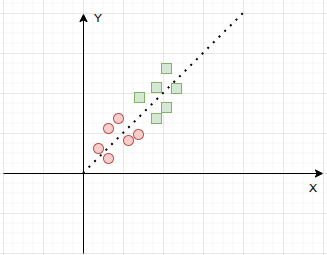

Based on this simple example, we can use the diagonal line as a new axis. So, let's re-draw the plot and apply this idea.

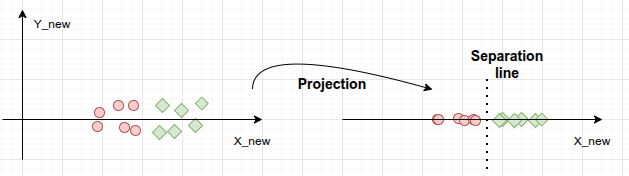

It is clear that the data exhibit much greater **spread** and **variability** along the new axis $X_{\text{new}}$ (the diagonal direction) than along $Y_{\text{new}}$ (the perpendicular direction).

If we project the data onto $X_{\text{new}}$ axis we can see clear separation line. But if we project onto $Y_{\text{new}}$ all the data sample will be tightly stacked on top of each other. **So, to catch the maximum variability we should pick up $X_{\text{new}}$ axis**. That is how **Principle Component Analysis** works.

Starting with data in two dimensions, we identified a single axis that accounts for the majority of the variability in the dataset. We then represented the data by projecting it onto this one-dimensional axis.

Why do we need that?


1. Dimensionality reduction (especially, when the features are of tens or hundreds dimensions): machine learning model now will work with less complicated data in lower dimension than the original;
2. Classes separation can be much easier in lower dimensional space;
3. Suppose we are given a new data sample without knowing whether it belongs to the red circles group or the diamonds group. By projecting this point onto the principal component $X_{\text{new}}$ axis, we can determine on which side of a chosen threshold it lies and assign it to the corresponding class.

## **Eigenvectors and eigenvalues**

The eigenvalue problem is defined as:  

$A \mathbf{x} = \lambda \mathbf{x}$  

where $A$ is a square matrix, $\lambda$ is an eigenvalue, and $\mathbf{x}$ is the corresponding eigenvector.

**Geometric meaning of eigenvectors**

In general, a linear transformation $A$ (rotation, reflection, shear, stretch, etc.) maps most vectors to new directions [[matrix operations](https://medium.com/@deneb.acyg/%D0%B2%D0%BB%D0%B0%D1%81%D0%BD%D1%96-%D0%B2%D0%B5%D0%BA%D1%82%D0%BE%D1%80%D0%B8-%D1%82%D0%B0-%D0%B2%D0%BB%D0%B0%D1%81%D0%BD%D1%96-%D0%B7%D0%BD%D0%B0%D1%87%D0%B5%D0%BD%D0%BD%D1%8F-e559263ba461)].
However, **eigenvectors** are special: applying $A$ to them does not change their direction, only their magnitude.  

- Eigenvectors span **invariant lines** through the origin.
- In other words, if $\mathbf{x}$ is an eigenvector, then $A \mathbf{x}$ stays on the same line as $\mathbf{x}$.


**Geometric meaning of eigenvalues**

The eigenvalue $\lambda$ tells us how the eigenvector is scaled:

- If $\lambda > 1$: the vector is stretched.
- If $0 < \lambda < 1$: the vector is shrunk.
- If $\lambda = 1$: the vector is unchanged (a fixed direction).
- If $\lambda = -1$: the vector is flipped but with the same length.
- If $\lambda < 0$: the vector is flipped and scaled.

**Orientation-preserving vs. reversing**

Eigenvalues also reveal whether orientation is preserved:

- If all eigenvalues are positive $\;\Rightarrow\;$ orientation is preserved along those eigen-directions.
- If some eigenvalues are negative $\;\Rightarrow\;$ those directions are flipped (orientation reversal).

**To sum this up**:
- **Eigenvectors** are the directions preserved by the transformation.
- **Eigenvalues** describe how much those directions are stretched, shrunk, or flipped.
- Together, they describe the "natural axes" of a linear transformation.

<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-1369886696.py:29: SyntaxWarning: invalid escape sequence '\l'
  f"$\lambda={val:.1f}$", fontsize=12)


Eigenvalues: [3. 2.]
Eigenvectors:
 [[ 1.         -0.70710678]
 [ 0.          0.70710678]]


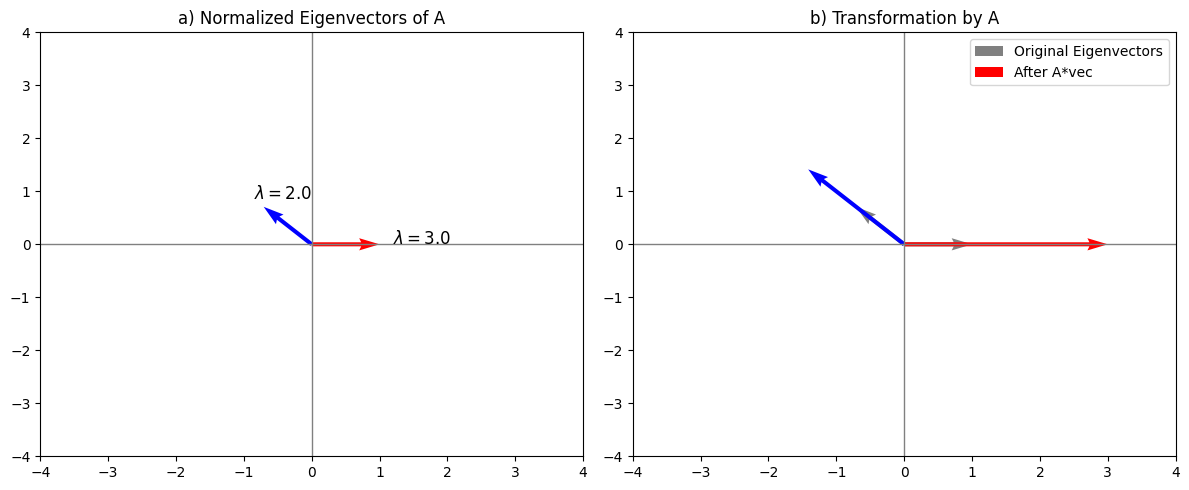

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define matrix A
A = np.array([[3, 1],
              [0, 2]])

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

print("Eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)

# Plot (a) Normalized eigenvectors with eigenvalues
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
origin = np.array([[0, 0],[0, 0]])  # origin for arrows
plt.quiver(*origin, eigvecs[0,:], eigvecs[1,:],
           angles='xy', scale_units='xy', scale=1,
           color=['r','b'])
plt.xlim(-4,4)   # symmetric limits
plt.ylim(-4,4)
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.title("a) Normalized Eigenvectors of A")
for i, val in enumerate(eigvals):
    plt.text(eigvecs[0,i]*1.2, eigvecs[1,i]*1.2,
             f"$\lambda={val:.1f}$", fontsize=12)

# Plot (b) Effect of multiplying by A
transformed = A @ eigvecs

plt.subplot(1,2,2)
plt.quiver(*origin, eigvecs[0,:], eigvecs[1,:],
           angles='xy', scale_units='xy', scale=1,
           color=['gray','gray'], label="Original Eigenvectors")
plt.quiver(*origin, transformed[0,:], transformed[1,:],
           angles='xy', scale_units='xy', scale=1,
           color=['r','b'], label="After A*vec")
plt.xlim(-4,4)   # symmetric limits
plt.ylim(-4,4)
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.title("b) Transformation by A")
plt.legend()

plt.tight_layout()
plt.show()

If a square matrix $A \in \mathbb{R}^{n \times n}$ is **symmetric** (i.e., $A = A^T$), then:  

- All of its **eigenvalues** are guaranteed to be **real**.  
- Its eigenvectors corresponding to distinct eigenvalues are **orthogonal**.  

This property makes symmetric matrices especially important in applications such as **Principal Component Analysis (PCA)** and many optimization problems.  

For example, consider the symmetric matrix:  

$
A = \begin{bmatrix} 2 & 1 \\ 1 & 3 \end{bmatrix}
$

We solve the eigenvalue problem:  

$
A \mathbf{x} = \lambda \mathbf{x}
$

The eigenvectors of this matrix will be real and orthogonal.

Eigenvalues: [1.38196601 3.61803399]
Eigenvectors:
 [[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]
Check orthogonality (dot product): 0.0


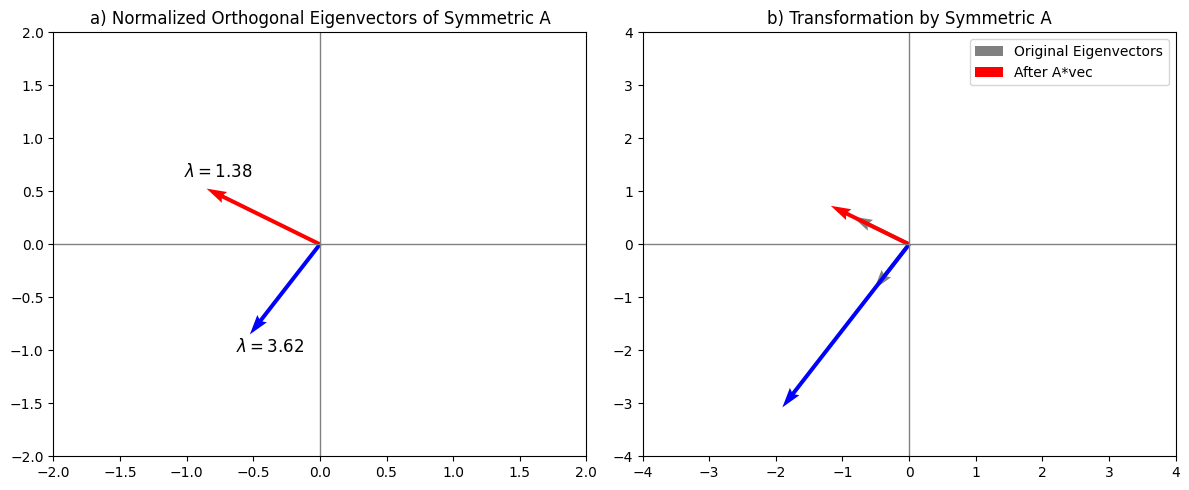

In [ ]:
# Define symmetric matrix A
A = np.array([[2, 1],
              [1, 3]])

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

print("Eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)
print("Check orthogonality (dot product):", np.dot(eigvecs[:,0], eigvecs[:,1]))

# Normalize eigenvectors for cleaner visualization
eigvecs = eigvecs / np.linalg.norm(eigvecs, axis=0)

# Plot (a) Eigenvectors with eigenvalues
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
origin = np.array([[0, 0],[0, 0]])  # origin for arrows
plt.quiver(*origin, eigvecs[0,:], eigvecs[1,:], angles='xy', scale_units='xy', scale=1, color=['r','b'])
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.title("a) Normalized Orthogonal Eigenvectors of Symmetric A")
for i, val in enumerate(eigvals):
    plt.text(eigvecs[0,i]*1.2, eigvecs[1,i]*1.2, f"$\\lambda={val:.2f}$", fontsize=12)

# Plot (b) Effect of multiplying by A
transformed = A @ eigvecs

plt.subplot(1,2,2)
plt.quiver(*origin, eigvecs[0,:], eigvecs[1,:], angles='xy', scale_units='xy', scale=1, color=['gray','gray'], label="Original Eigenvectors")
plt.quiver(*origin, transformed[0,:], transformed[1,:], angles='xy', scale_units='xy', scale=1, color=['r','b'], label="After A*vec")
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.title("b) Transformation by Symmetric A")
plt.legend()

plt.tight_layout()
plt.show()

## **Variance and Covariance for Real Datasets**

Let $X$ and $Y$ be two features (columns) in a dataset with $n$ observations.



**Variance**

Variance measures the spread of a single variable around its mean:

$$
\mathrm{Var}(X) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{X})^2
\quad \text{or with Bessel's correction:} \quad
\mathrm{Var}(X) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{X})^2
$$

$$
\mathrm{Var}(Y) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{Y})^2
\quad \text{or with Bessel's correction:} \quad
\mathrm{Var}(Y) = \frac{1}{n-1} \sum_{i=1}^{n} (y_i - \bar{Y})^2
$$

where

$$
\bar{X} = \frac{1}{n}\sum_{i=1}^{n} x_i, \quad
\bar{Y} = \frac{1}{n}\sum_{i=1}^{n} y_i
$$


**Covariance**

Covariance measures how two variables vary together:

$$
\mathrm{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{X})(y_i - \bar{Y})
\quad \text{or with Bessel's correction:} \quad
\mathrm{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{X})(y_i - \bar{Y})
$$

- $\mathrm{Cov}(X, Y) > 0$: $X$ and $Y$ tend to increase together.  
- $\mathrm{Cov}(X, Y) < 0$: $X$ increases, $Y$ tends to decrease.  
- $\mathrm{Cov}(X, Y) = 0$: $X$ and $Y$ are uncorrelated.

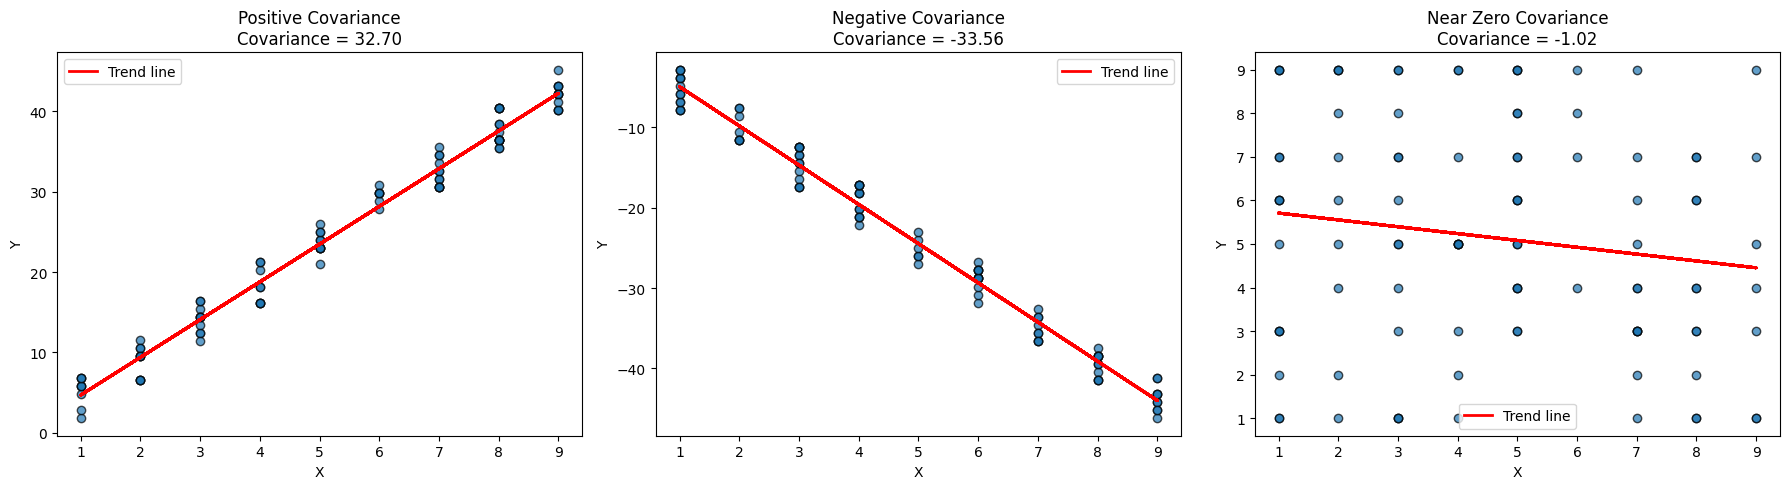

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(42)
n = 100

# Generate three scenarios
X1 = np.random.randint(1, 10, size=n)
Y1 = 4.8 * X1 + np.random.randint(-3, 3, size=n)       # Positive covariance

X2 = np.random.randint(1, 10, size=n)
Y2 = -4.8 * X2 + np.random.randint(-3, 3, size=n)      # Negative covariance

X3 = np.random.randint(1, 10, size=n)
Y3 = np.random.randint(1, 10, size=n)               # Near zero covariance

datasets = [(X1, Y1, "Positive Covariance"),
            (X2, Y2, "Negative Covariance"),
            (X3, Y3, "Near Zero Covariance")]

plt.figure(figsize=(18, 5))

for i, (X, Y, title) in enumerate(datasets, 1):
    plt.subplot(1, 3, i)
    plt.scatter(X, Y, alpha=0.7, edgecolor='k')
    m, b = np.polyfit(X, Y, 1)
    plt.plot(X, m*X + b, color='red', linewidth=2, label="Trend line")
    cov_XY = np.cov(X, Y, ddof=1)[0, 1]
    plt.title(f"{title}\nCovariance = {cov_XY:.2f}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

plt.tight_layout()
plt.show()

This concept also clearly explained by Josh Starmer [StatQuest](https://www.youtube.com/watch?v=qtaqvPAeEJY).

### **Relation to Linear Regression**

If you fit a simple linear regression:

$$
Y = m X + b
$$

the slope is:

$$
m = \frac{\mathrm{Cov}(X, Y)}{\mathrm{Var}(X)}
$$

So the slope is **covariance divided by the variance of $X$**.

This is why the trend line in your plot roughly follows the direction of the covariance:

- Positive covariance → upward slope  
- Negative covariance → downward slope.


## **Covariance Matrix**

Let’s consider a small dataset \(X\) with 3 features and 4 observations:

$$
X =
\begin{bmatrix}
5 & 7 & 8 \\
2 & 6 & 5 \\
4 & 4 & 7 \\
7 & 8 & 6
\end{bmatrix}
$$

Columns represent:  
- Column 1: `studying_hours`  
- Column 2: `sleeping_hours`  
- Column 3: `visited_lectures`  

We center the dataset by **subtracting the mean of each feature**:

$$
\bar{X} =
\begin{bmatrix}
\bar{x}_1 & \bar{x}_2 & \bar{x}_3
\end{bmatrix}
= \begin{bmatrix}
4.5 & 6.25 & 6.5
\end{bmatrix}
$$

Centered matrix $X_{centered} = X - \bar{X}$:

$$
X_{centered} =
\begin{bmatrix}
0.5 & 0.75 & 1.5 \\
-2.5 & -0.25 & -1.5 \\
-0.5 & -2.25 & 0.5 \\
2.5 & 1.75 & -0.5
\end{bmatrix}
$$

The transposed matrix is:

$$
X_{centered}^T =
\begin{bmatrix}
0.5 & -2.5 & -0.5 & 2.5 \\
0.75 & -0.25 & -2.25 & 1.75 \\
1.5 & -1.5 & 0.5 & -0.5
\end{bmatrix}
$$

 **Covariance Matrix**

Covariance matrix is calculated as:

$$
\text{Cov}(X) = \frac{1}{n-1} X_{centered}^T X_{centered} \quad (n = 4)
$$

Step by step, each element is:

$$
\text{Cov}(X)_{ij} = \frac{1}{n-1} \sum_{k=1}^{n} (x_{ki} - \bar{x}_i)(x_{kj} - \bar{x}_j)
$$

Resulting in:

$$
\text{Cov}(X) =
\begin{bmatrix}
4.333 & 2.083 & 1.833 \\
2.083 & 3.583 & 0.833 \\
1.833 & 0.833 & 2.333
\end{bmatrix}
$$

**Diagonal elements**: $\text{Cov}(X)_{ii} = \text{Var}(x_i)$, the variance of each feature.  
- **Non-diagonal elements**: $\text{Cov}(X)_{ij} = \text{Cov}(x_i, x_j)$, the covariance between two different features.  

- Positive covariance → features tend to increase together.  
- Negative covariance → one feature increases while the other decreases.  
- Zero → features are uncorrelated.

## **PCA in Action**

The eigenvectors of a covariance matrix are the principal components of the original dataset $\textbf{X}$. Intuitively, here’s why: the covariance matrix captures how each feature varies relative to the others, it encodes the directions of variability in the data. Eigenvectors point along the axes where the data show the largest variation, while the corresponding eigenvalues tell you how much variance exists along those axes.

In other words, principal components are new axes for your data:

1. They are linear combinations of the original features.

2. They are uncorrelated with each other.

3. The first principal component captures the most variance, the second captures the next most variance, and so on.

By projecting the data onto these eigenvectors, we can reduce dimensionality while preserving as much information (variance) as possible, because we are essentially keeping the directions along which the data vary the most.

Now, let's combine the all revealed parts into single PCA algorithm and implement it. We are using **IRIS** dataset here, which is standard for different benchmarks.

Text(0.5, 1.0, 'PCA of IRIS dataset')

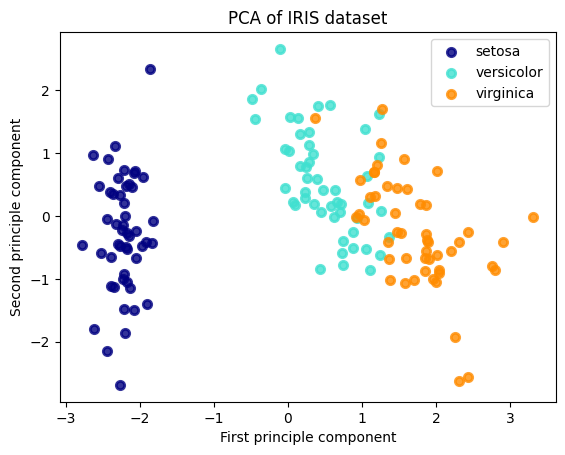

In [ ]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 1. Data Standardization along the Features
scaler = StandardScaler()
scaled = scaler.fit_transform(X)

# 2. Calculate covariance matrix
cov_matrix = np.cov(scaled, ddof=1, rowvar = False)

# 3. Compute eigenvectors and eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 4. Sort eigenvectors from the most important to the least important
order_of_importance = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[order_of_importance]
sorted_eigenvectors = eigenvectors[:,order_of_importance] # sort the columns

# 5. Reduce the data
k = 2
reduced = scaled @ sorted_eigenvectors[:,:k]

# visualize
colors = ["navy", "turquoise", "darkorange"]
lw = 2
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(
        reduced[y == i, 0], reduced[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("First principle component")
plt.ylabel("Second principle component")
plt.title("PCA of IRIS dataset")

In [ ]:
# Total variance
total_variance = np.sum(sorted_eigenvalues)

# Fraction of variance explained
explained_variance_ratio = sorted_eigenvalues / total_variance

print("Explained variance ratio for each PC:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

Explained variance ratio for each PC:
PC1: 0.7296 (72.96%)
PC2: 0.2285 (22.85%)
PC3: 0.0367 (3.67%)
PC4: 0.0052 (0.52%)


In [ ]:
cumulative_variance = np.cumsum(explained_variance_ratio)
print("Cumulative variance explained:")
for i, ratio in enumerate(cumulative_variance):
    print(f"PC1 to PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

Cumulative variance explained:
PC1 to PC1: 0.7296 (72.96%)
PC1 to PC2: 0.9581 (95.81%)
PC1 to PC3: 0.9948 (99.48%)
PC1 to PC4: 1.0000 (100.00%)


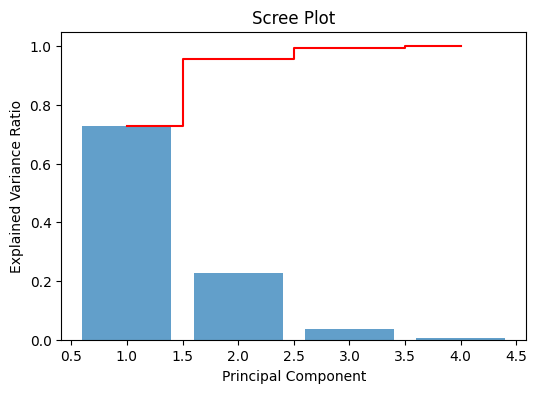

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, alpha=0.7, align='center')
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where='mid', color='red')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

## **Disclaimer**

1. Never underestimate the importance of **domain knowledge**: **PCA** may discard features that are important for the task or highlight features that are not relevant.

2. **PCA** is a **linear method**: If the dataset has significant non-linear patterns, PCA may fail to capture them effectively.

3. Sometimes higher-dimensional projections are useful: to achieve better data separability, mapping the dataset into a higher-dimensional space (rather than reducing dimensions) can be beneficial (**Support Vector Machines**).

More in book "Why Machines Learn" (Chapter 6):

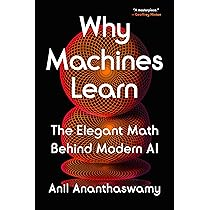

**References**:

[StatQuest](https://www.youtube.com/watch?v=FgakZw6K1QQ)

[Blog post](https://medium.com/@deneb.acyg/%D0%BC%D0%B0%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D0%BA%D0%B0-%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE-%D0%BD%D0%B0%D0%B2%D1%87%D0%B0%D0%BD%D0%BD%D1%8F-%D0%BC%D0%B5%D1%82%D0%BE%D0%B4-%D0%B3%D0%BE%D0%BB%D0%BE%D0%B2%D0%BD%D0%B8%D1%85-%D0%BA%D0%BE%D0%BC%D0%BF%D0%BE%D0%BD%D0%B5%D0%BD%D1%82-%D1%87%D0%B0%D1%81%D1%82%D0%B8%D0%BD%D0%B0-2-023152e7fd29)

[Paper which explains PCA](https://www.cs.cmu.edu/~elaw/papers/pca.pdf)